<a href="https://colab.research.google.com/github/CuicuiZhang01/DTSC5082_Project_Delivery-Delay-Predictor/blob/main/DTSC5082_delivery_delay_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
!pip install shap -q

In [ ]:
import shap

# **Load Dataset and Data Exploration**

In [ ]:
df = pd.read_csv("amazon_delivery.csv")

print("Dataset shape:", df.shape)
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys



Data types:
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object

Missing values:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64


In [ ]:
TARGET = "Delivery_Time"

In [ ]:
df = df.copy()

# Remove duplicate rows
df = df.drop_duplicates()

# Convert date/time
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Order_Time"] = pd.to_datetime(
    df["Order_Time"], format="%H:%M:%S", errors="coerce"
)
df["Pickup_Time"] = pd.to_datetime(
    df["Pickup_Time"], format="%H:%M:%S", errors="coerce"
)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (43739, 16)


# **Data Preprocessing and Feature Engineering**

In [ ]:
# Feature Engineering

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


df["Distance_km"] = haversine_distance(
    df["Store_Latitude"],
    df["Store_Longitude"],
    df["Drop_Latitude"],
    df["Drop_Longitude"]
)

In [ ]:
df["Order_Hour"] = df["Order_Time"].dt.hour

In [ ]:
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

In [ ]:
order_minutes = (
    df["Order_Time"].dt.hour * 60
    + df["Order_Time"].dt.minute
)

pickup_minutes = (
    df["Pickup_Time"].dt.hour * 60
    + df["Pickup_Time"].dt.minute
)

df["Pickup_Wait_Min"] = pickup_minutes - order_minutes

# Handle orders crossing midnight
df.loc[df["Pickup_Wait_Min"] < 0, "Pickup_Wait_Min"] += 24 * 60

In [ ]:
# Feature Selection

features = [
    "Agent_Age",
    "Agent_Rating",
    "Distance_km",
    "Pickup_Wait_Min",
    "Order_Hour",
    "Day_of_Week",
    "Weather",
    "Traffic",
    "Vehicle",
    "Area",
    "Category"
]

X = df[features]
y = df["Delivery_Time"]

print("Features:")
print(X.columns.tolist())

print("\nTarget summary:")
print(y.describe())

Features:
['Agent_Age', 'Agent_Rating', 'Distance_km', 'Pickup_Wait_Min', 'Order_Hour', 'Day_of_Week', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Category']

Target summary:
count    43739.000000
mean       124.905645
std         51.915451
min         10.000000
25%         90.000000
50%        125.000000
75%        160.000000
max        270.000000
Name: Delivery_Time, dtype: float64


In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 34991
Testing samples: 8748


In [ ]:
# Preprocessing Pipeline

numeric_features = [
    "Agent_Age",
    "Agent_Rating",
    "Distance_km",
    "Pickup_Wait_Min",
    "Order_Hour"
]

categorical_features = [
    "Day_of_Week",
    "Weather",
    "Traffic",
    "Vehicle",
    "Area",
    "Category"
]

In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# **Load Saved Models**

In [ ]:
import joblib

best_linear_model = joblib.load("linear_best_model.pkl")
best_dt_model = joblib.load("dt_best_model.pkl")
best_rf_model = joblib.load("rf_best_model.pkl")
best_xgb_model = joblib.load("xgb_best_model.pkl")
best_svr_model = joblib.load("svr_best_model.pkl")
best_mlp_model = joblib.load("mlp_best_model.pkl")

print("All models loaded successfully.")

All models loaded successfully.


# **1. Linear Regression**
 - Baseline

In [ ]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [ ]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 3))

Linear Regression
MAE : 26.09
RMSE: 33.12
R²  : 0.588


# **1. Linear Regression**
  - GridSearchCV

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# Linear Regression pipeline
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Hyperparameter search space
param_grid = {
    "model__fit_intercept": [True, False]
}

# Grid Search with 5-fold cross-validation
linear_search = GridSearchCV(
    estimator=linear_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=2,
    verbose=1
)

# Train and record search time
start_time = time.time()

linear_search.fit(X_train, y_train)

search_time = (time.time() - start_time) / 60

# Best parameters
print("Search time:", round(search_time, 2), "minutes")
print("Best parameters:", linear_search.best_params_)
print(
    "Best cross-validation RMSE:",
    round(-linear_search.best_score_, 2)
)

# Best model
best_linear_model = linear_search.best_estimator_

# Predict
linear_tuned_pred = best_linear_model.predict(X_test)

# Evaluate
linear_tuned_mae = mean_absolute_error(y_test, linear_tuned_pred)
linear_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, linear_tuned_pred)
)
linear_tuned_r2 = r2_score(y_test, linear_tuned_pred)

print("\nTuned Linear Regression")
print("MAE :", round(linear_tuned_mae, 2))
print("RMSE:", round(linear_tuned_rmse, 2))
print("R²  :", round(linear_tuned_r2, 3))

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Search time: 0.02 minutes
Best parameters: {'model__fit_intercept': False}
Best cross-validation RMSE: 33.32

Tuned Linear Regression
MAE : 26.09
RMSE: 33.12
R²  : 0.588


# **2. Decision Tree**
  - Baseline

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Decision Tree pipeline
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=2,
        random_state=42
    ))
])

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluate
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R²  :", round(dt_r2, 3))

Decision Tree
MAE : 18.32
RMSE: 24.2
R²  : 0.78


# **2. Decision Tree**
 - GridSearchCV tuning

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Decision Tree pipeline
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Hyperparameter grid
param_grid = {
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}

# Grid Search with 5-fold cross-validation
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Train and tune
dt_grid.fit(X_train, y_train)

# Best parameters
print("Best parameters:")
print(dt_grid.best_params_)

# Best model
best_dt_model = dt_grid.best_estimator_

# Predict on test set
dt_pred = best_dt_model.predict(X_test)

# Evaluate
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("\nTuned Decision Tree")
print("MAE :", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R²  :", round(dt_r2, 3))

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}

Tuned Decision Tree
MAE : 17.04
RMSE: 22.13
R²  : 0.816


# **3. Random Forest**
   - Baseline

In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 3))

Random Forest
MAE : 16.82
RMSE: 21.74
R²  : 0.823


## **3. Random Forest**
 - RandomizedSearchCV

In [ ]:
from time import perf_counter

import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=1,
    )),
])

# Hyperparameter search space
param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    verbose=2,
    error_score="raise",
)

# Train and tune
start = perf_counter()
rf_search.fit(X_train, y_train)
elapsed = perf_counter() - start

# Best model and cross-validation results
best_rf_model = rf_search.best_estimator_

print(f"\nSearch time: {elapsed / 60:.1f} minutes")
print("Best parameters:", rf_search.best_params_)
print(f"Best cross-validation RMSE: {-rf_search.best_score_:.2f}")

# Predict on the test set
rf_pred = best_rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nTuned Random Forest")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Search time: 144.1 minutes
Best parameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 10}
Best cross-validation RMSE: 22.23

Tuned Random Forest
MAE : 16.82
RMSE: 21.68
R²  : 0.823


# **4. XGBoost**
- Baseline

In [ ]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 3))

XGBoost
MAE : 17.14
RMSE: 21.97
R²  : 0.819


# **4. XGBoost**
- RandomizedSearchCV

In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

# XGBoost pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparameter search space
param_dist = {
    "model__n_estimators": [500, 700, 1000],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

# Randomized Search with 5-fold cross-validation
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2,
    verbose=1
)

# Train and tune
start_time = time.time()

xgb_search.fit(X_train, y_train)

search_time = (time.time() - start_time) / 60

# Best parameters
print("\nSearch time:", round(search_time, 1), "minutes")

print("\nBest parameters:")
print(xgb_search.best_params_)

print(
    "Best cross-validation RMSE:",
    round(-xgb_search.best_score_, 2)
)

# Best model
best_xgb_model = xgb_search.best_estimator_

# Predict on test set
xgb_tuned_pred = best_xgb_model.predict(X_test)

# Evaluate
xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_pred)
xgb_tuned_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_tuned_pred)
)
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_pred)

print("\nTuned XGBoost")
print("MAE :", round(xgb_tuned_mae, 2))
print("RMSE:", round(xgb_tuned_rmse, 2))
print("R²  :", round(xgb_tuned_r2, 3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Search time: 2.5 minutes

Best parameters:
{'model__subsample': 0.9, 'model__n_estimators': 700, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}
Best cross-validation RMSE: 22.37

Tuned XGBoost
MAE : 16.97
RMSE: 21.88
R²  : 0.82


# **5. SVM**
 - Baseline

In [ ]:
from sklearn.svm import SVR

# SVR pipeline
svr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.1
    ))
])

# Train
svr_model.fit(X_train, y_train)

# Predict
svr_pred = svr_model.predict(X_test)

# Evaluate
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)

print("SVR")
print("MAE :", round(svr_mae, 2))
print("RMSE:", round(svr_rmse, 2))
print("R²  :", round(svr_r2, 3))

SVR
MAE : 22.42
RMSE: 29.12
R²  : 0.682


# **5. SVR**
- RandomizedSearchCV


In [ ]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

svr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(kernel="rbf"))
])

param_dist = {
    "model__C": [1, 10, 50, 100, 500],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "model__epsilon": [0.01, 0.1, 0.2, 0.5, 1.0]
}

svr_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    verbose=1
)

start_time = time.time()

svr_search.fit(X_train, y_train)

search_time = (time.time() - start_time) / 60

print("Search time:", round(search_time, 1), "minutes")
print("Best parameters:", svr_search.best_params_)
print("Best cross-validation RMSE:",
      round(-svr_search.best_score_, 2))

best_svr_model = svr_search.best_estimator_

svr_tuned_pred = best_svr_model.predict(X_test)

svr_tuned_mae = mean_absolute_error(y_test, svr_tuned_pred)
svr_tuned_rmse = np.sqrt(mean_squared_error(y_test, svr_tuned_pred))
svr_tuned_r2 = r2_score(y_test, svr_tuned_pred)

print("\nTuned SVR")
print("MAE :", round(svr_tuned_mae, 2))
print("RMSE:", round(svr_tuned_rmse, 2))
print("R²  :", round(svr_tuned_r2, 3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Search time: 228.5 minutes
Best parameters: {'model__gamma': 'auto', 'model__epsilon': 0.5, 'model__C': 500}
Best cross-validation RMSE: 29.31

Tuned SVR
MAE : 22.12
RMSE: 28.94
R²  : 0.686


# **6.MLP**
 - Baseline

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MLP pipeline
mlp_model = Pipeline([
    ("preprocessor", preprocessor),

    ("model", MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])

# Train
mlp_model.fit(X_train, y_train)

# Predict
mlp_pred = mlp_model.predict(X_test)

# Evaluate
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_r2 = r2_score(y_test, mlp_pred)

print("MLP")
print("MAE :", round(mlp_mae, 2))
print("RMSE:", round(mlp_rmse, 2))
print("R²  :", round(mlp_r2, 3))

MLP
MAE : 21.04
RMSE: 27.5
R²  : 0.716


# **MLP**
- Randomized Search CV

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

mlp_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", MLPRegressor(
        solver="adam",
        max_iter=500,
        early_stopping=True,
        random_state=42
    ))
])


param_dist = {
    "model__hidden_layer_sizes": [
        (100, 50),
        (128, 64),
        (100, 50, 25)
    ],

    "model__activation": [
        "relu",
        "tanh"
    ],

    "model__alpha": [
        0.0001,
        0.001,
        0.01
    ],

    "model__learning_rate_init": [
        0.0005,
        0.001,
        0.005
    ]
}


# Randomized Search + 5-Fold Cross-Validation
mlp_search = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=2,
    pre_dispatch=2,
    verbose=1,
    error_score="raise"
)


# Train and Record Search Time
start_time = time.time()
mlp_search.fit(X_train, y_train)
search_time = (time.time() - start_time) / 60

# Best Parameters and CV Performance
print("\nSearch time:", round(search_time, 1), "minutes")
print("\nBest parameters:")
print(mlp_search.best_params_)
print(
    "Best cross-validation RMSE:",
    round(-mlp_search.best_score_, 2)
)

# Best Model
best_mlp_model = mlp_search.best_estimator_

# Test Set Prediction
mlp_tuned_pred = best_mlp_model.predict(X_test)


# Final Test Performance
mlp_tuned_mae = mean_absolute_error(
    y_test,
    mlp_tuned_pred
)

mlp_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        mlp_tuned_pred
    )
)

mlp_tuned_r2 = r2_score(
    y_test,
    mlp_tuned_pred
)


print("\nTuned MLP")
print("MAE :", round(mlp_tuned_mae, 2))
print("RMSE:", round(mlp_tuned_rmse, 2))
print("R²  :", round(mlp_tuned_r2, 3))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Search time: 34.8 minutes

Best parameters:
{'model__learning_rate_init': 0.0005, 'model__hidden_layer_sizes': (100, 50, 25), 'model__alpha': 0.0001, 'model__activation': 'tanh'}
Best cross-validation RMSE: 25.31

Tuned MLP
MAE : 18.8
RMSE: 24.44
R²  : 0.776


# **Baseline Model Comparison**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_models = {
    "Linear Regression": linear_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "SVR": svr_model,
    "MLP": mlp_model
}

baseline_results = []

# Evaluate baseline models
for name, model in baseline_models.items():
    pred = model.predict(X_test)

    baseline_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

# Create comparison table
baseline_results = pd.DataFrame(baseline_results)

# Sort by RMSE
baseline_results = baseline_results.sort_values("RMSE").reset_index(drop=True)

print("Baseline Model Comparison")
display(baseline_results.round(3))

Baseline Model Comparison


,Model,MAE,RMSE,R2
0,Random Forest,16.818,21.741,0.823
1,XGBoost,17.137,21.966,0.819
2,Decision Tree,18.318,24.204,0.780
3,MLP,21.045,27.505,0.716
4,SVR,22.417,29.116,0.682
5,Linear Regression,26.091,33.118,0.588


# **Tuned Model Comparison**

In [ ]:
models = {
    "Linear Regression": best_linear_model,
    "Decision Tree": best_dt_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_xgb_model,
    "SVR": best_svr_model,
    "MLP": best_mlp_model
}

results = []

# Evaluate each tuned model
for name, model in models.items():
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Create comparison table
tuned_results = pd.DataFrame(results)

# Sort by RMSE
tuned_results = tuned_results.sort_values("RMSE").reset_index(drop=True)

print("Tuned Model Comparison")
display(tuned_results.round(3))

Tuned Model Comparison


,Model,MAE,RMSE,R2
0,Random Forest,16.815,21.684,0.823
1,XGBoost,16.971,21.882,0.820
2,Decision Tree,17.042,22.132,0.816
3,MLP,18.795,24.439,0.776
4,SVR,22.118,28.937,0.686
5,Linear Regression,26.091,33.118,0.588


# **Best Model Visualization**

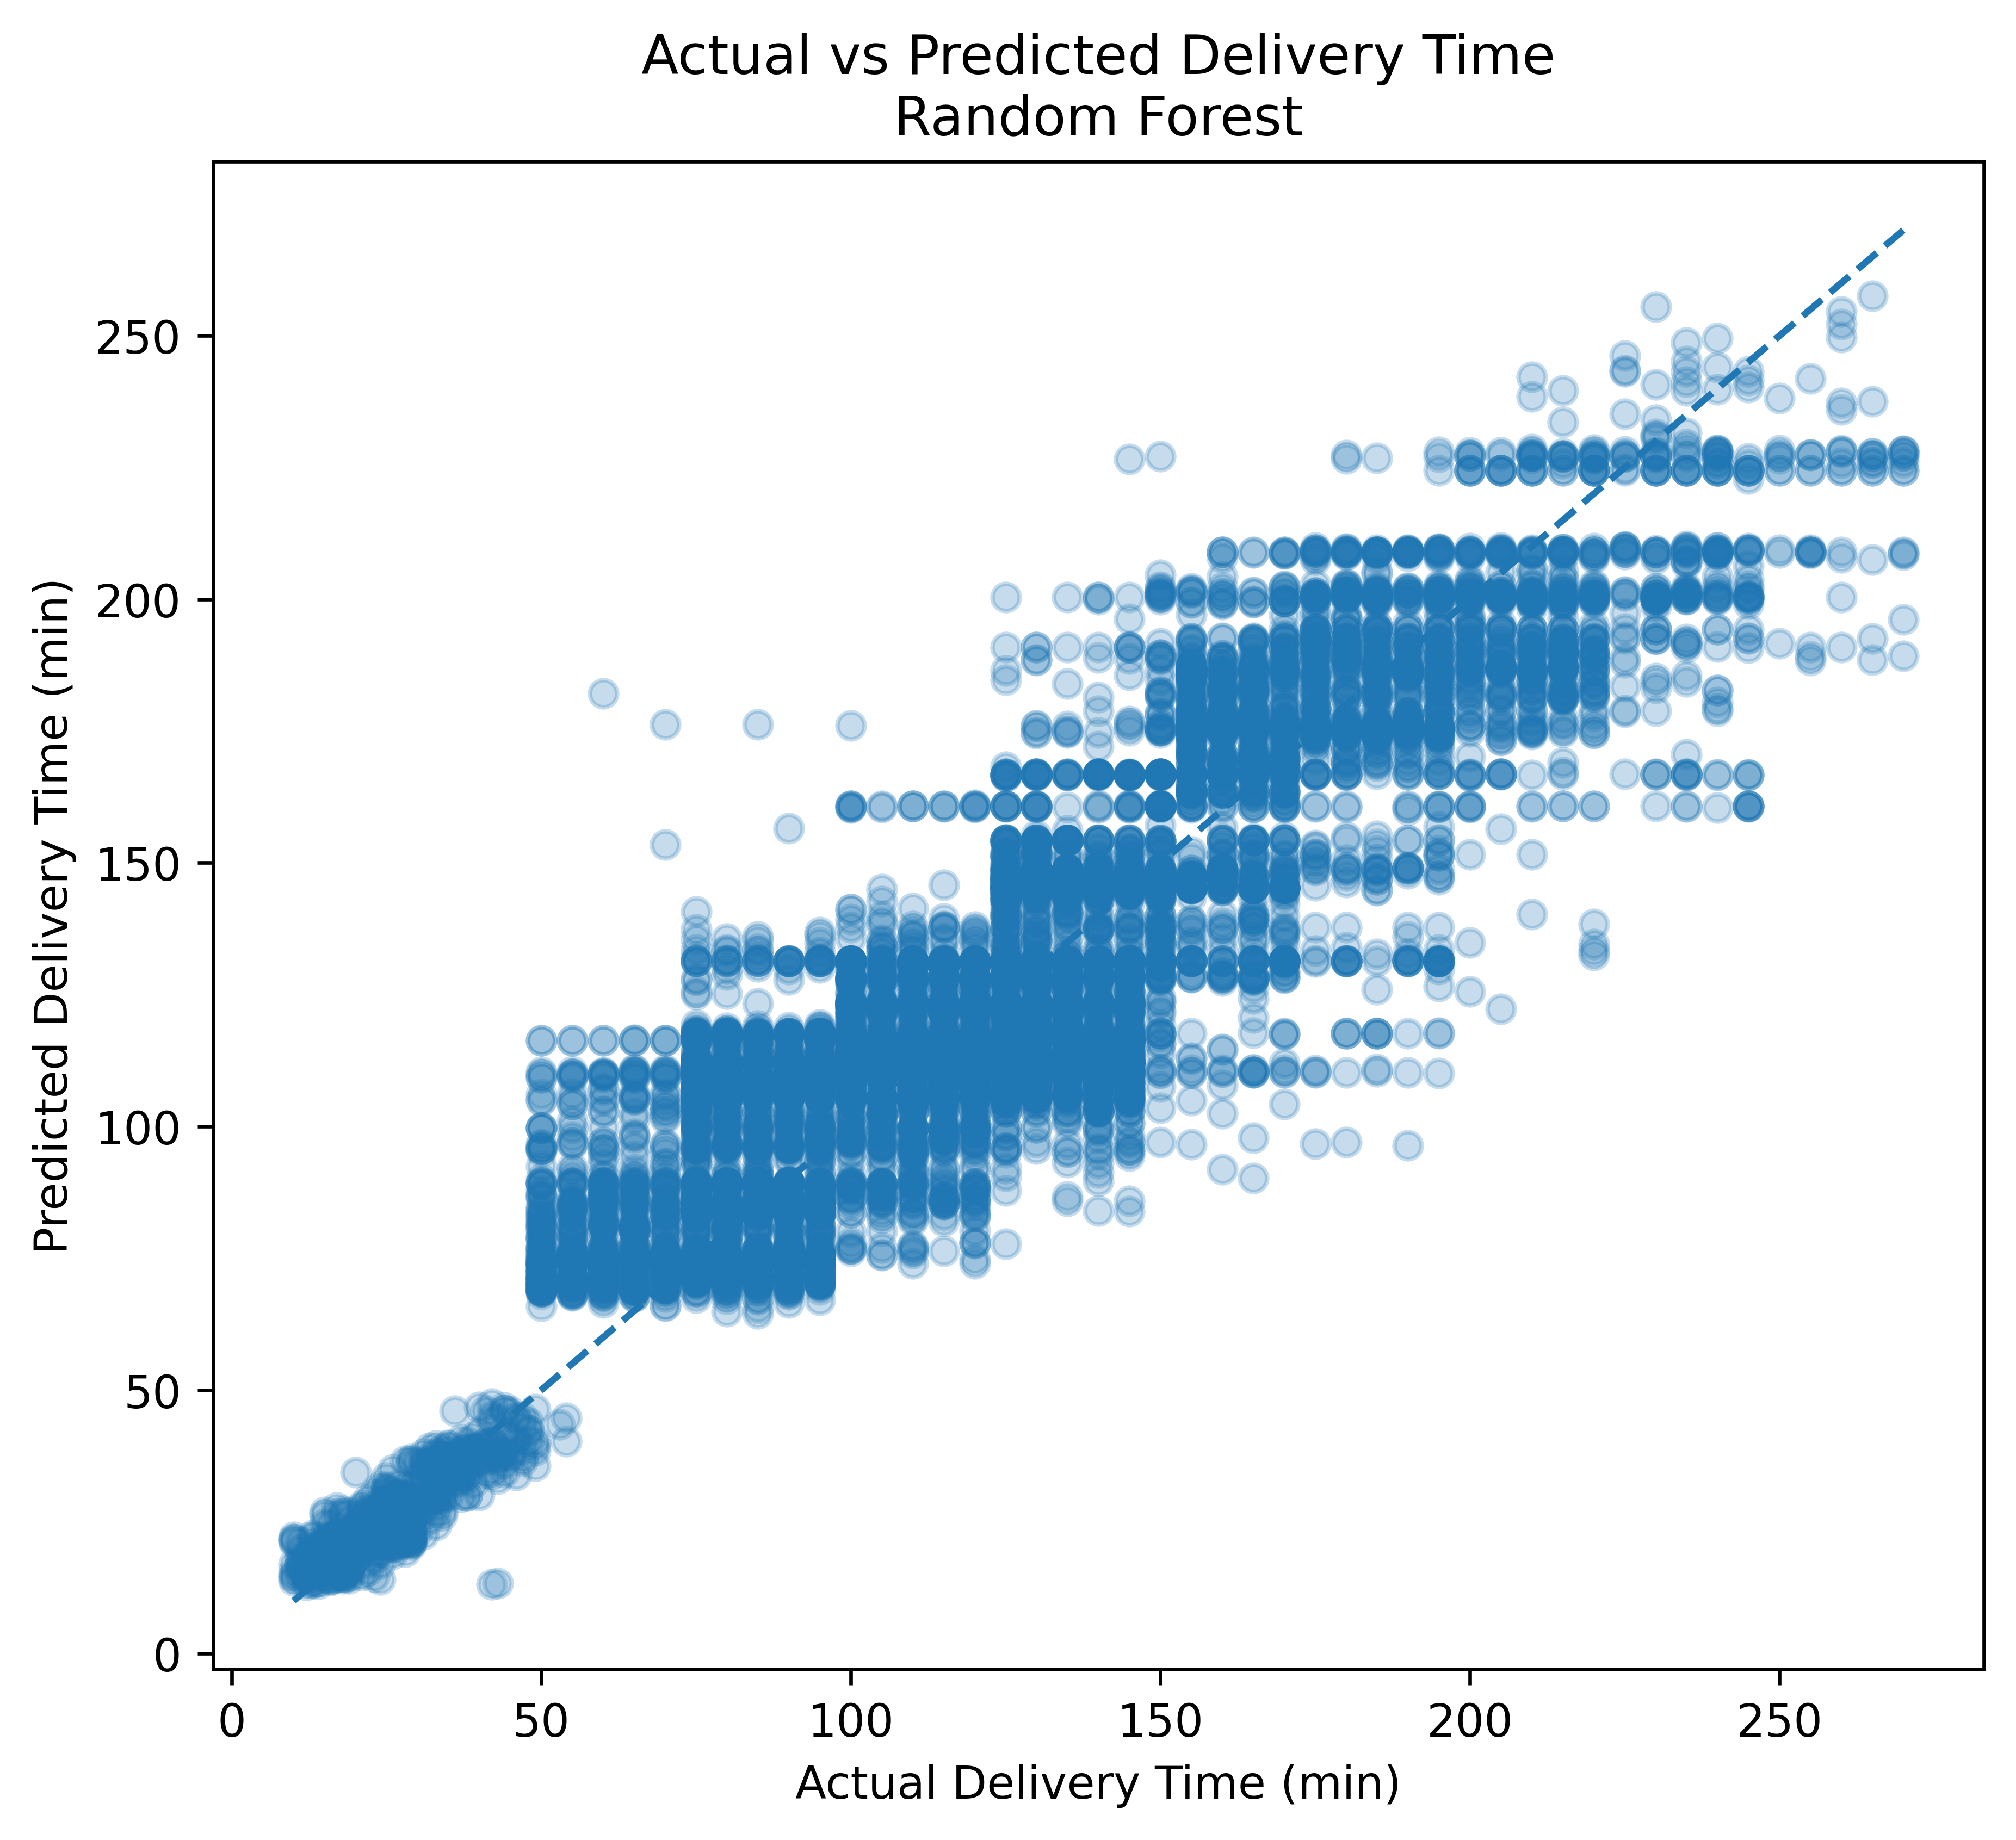

In [ ]:
rf_pred = best_rf_model.predict(X_test)

plt.figure(figsize=(7, 6), dpi=600)

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.25
)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Actual vs Predicted Delivery Time\nRandom Forest")

plt.show()

# **SHAP Analysis**

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Get preprocessor and Random Forest model from pipeline
preprocessor = best_rf_model.named_steps["preprocessor"]
rf_model = best_rf_model.named_steps["model"]

# Use the entire test set for SHAP analysis
X_shap = X_test.copy()

# Apply preprocessing
X_shap_transformed = preprocessor.transform(X_shap)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names
)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer(X_shap_df)

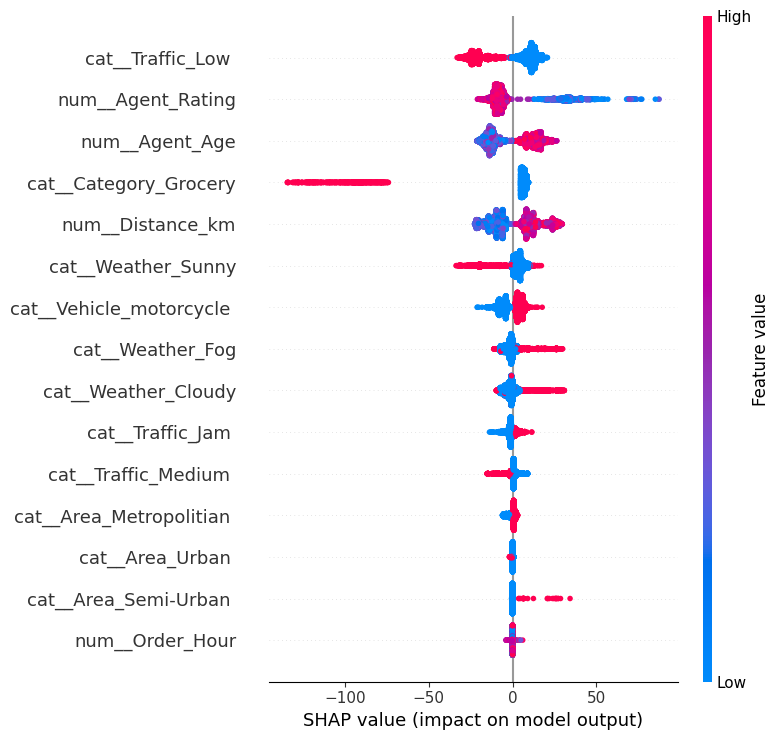

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap_df,
    max_display=15
)

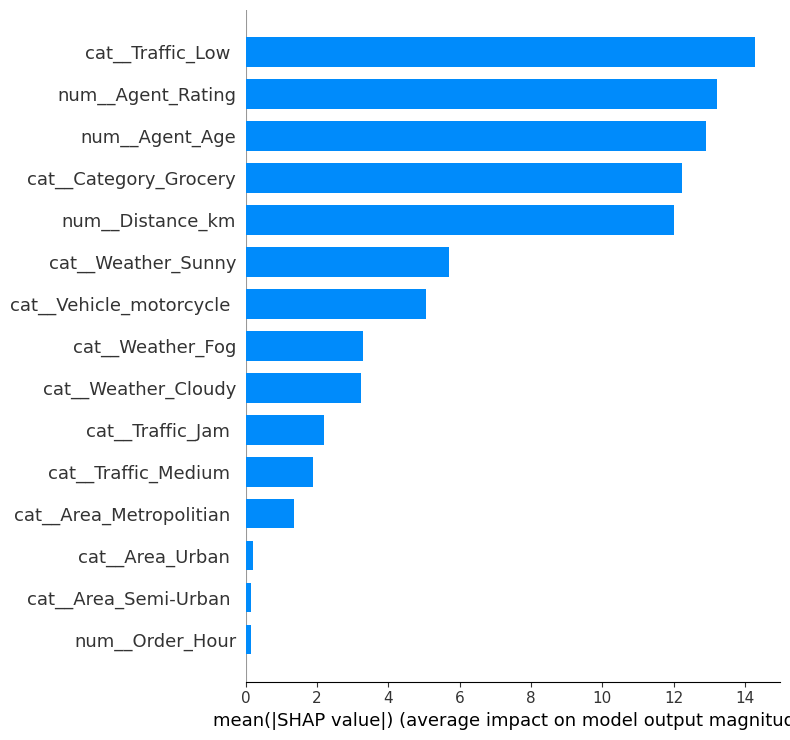

In [ ]:
# SHAP Feature Importance
shap.summary_plot(
    shap_values,
    X_shap_df,
    plot_type="bar",
    max_display=15
)

# **Risk Level Analysis**

In [ ]:
# Define risk thresholds from training data
low_threshold = y_train.quantile(0.50)
high_threshold = y_train.quantile(0.75)

print("P50 threshold:", low_threshold)
print("P75 threshold:", high_threshold)

def get_risk_level(time):
    if time <= low_threshold:
        return "LOW"
    elif time <= high_threshold:
        return "MEDIUM"
    else:
        return "HIGH"

P50 threshold: 125.0
P75 threshold: 160.0


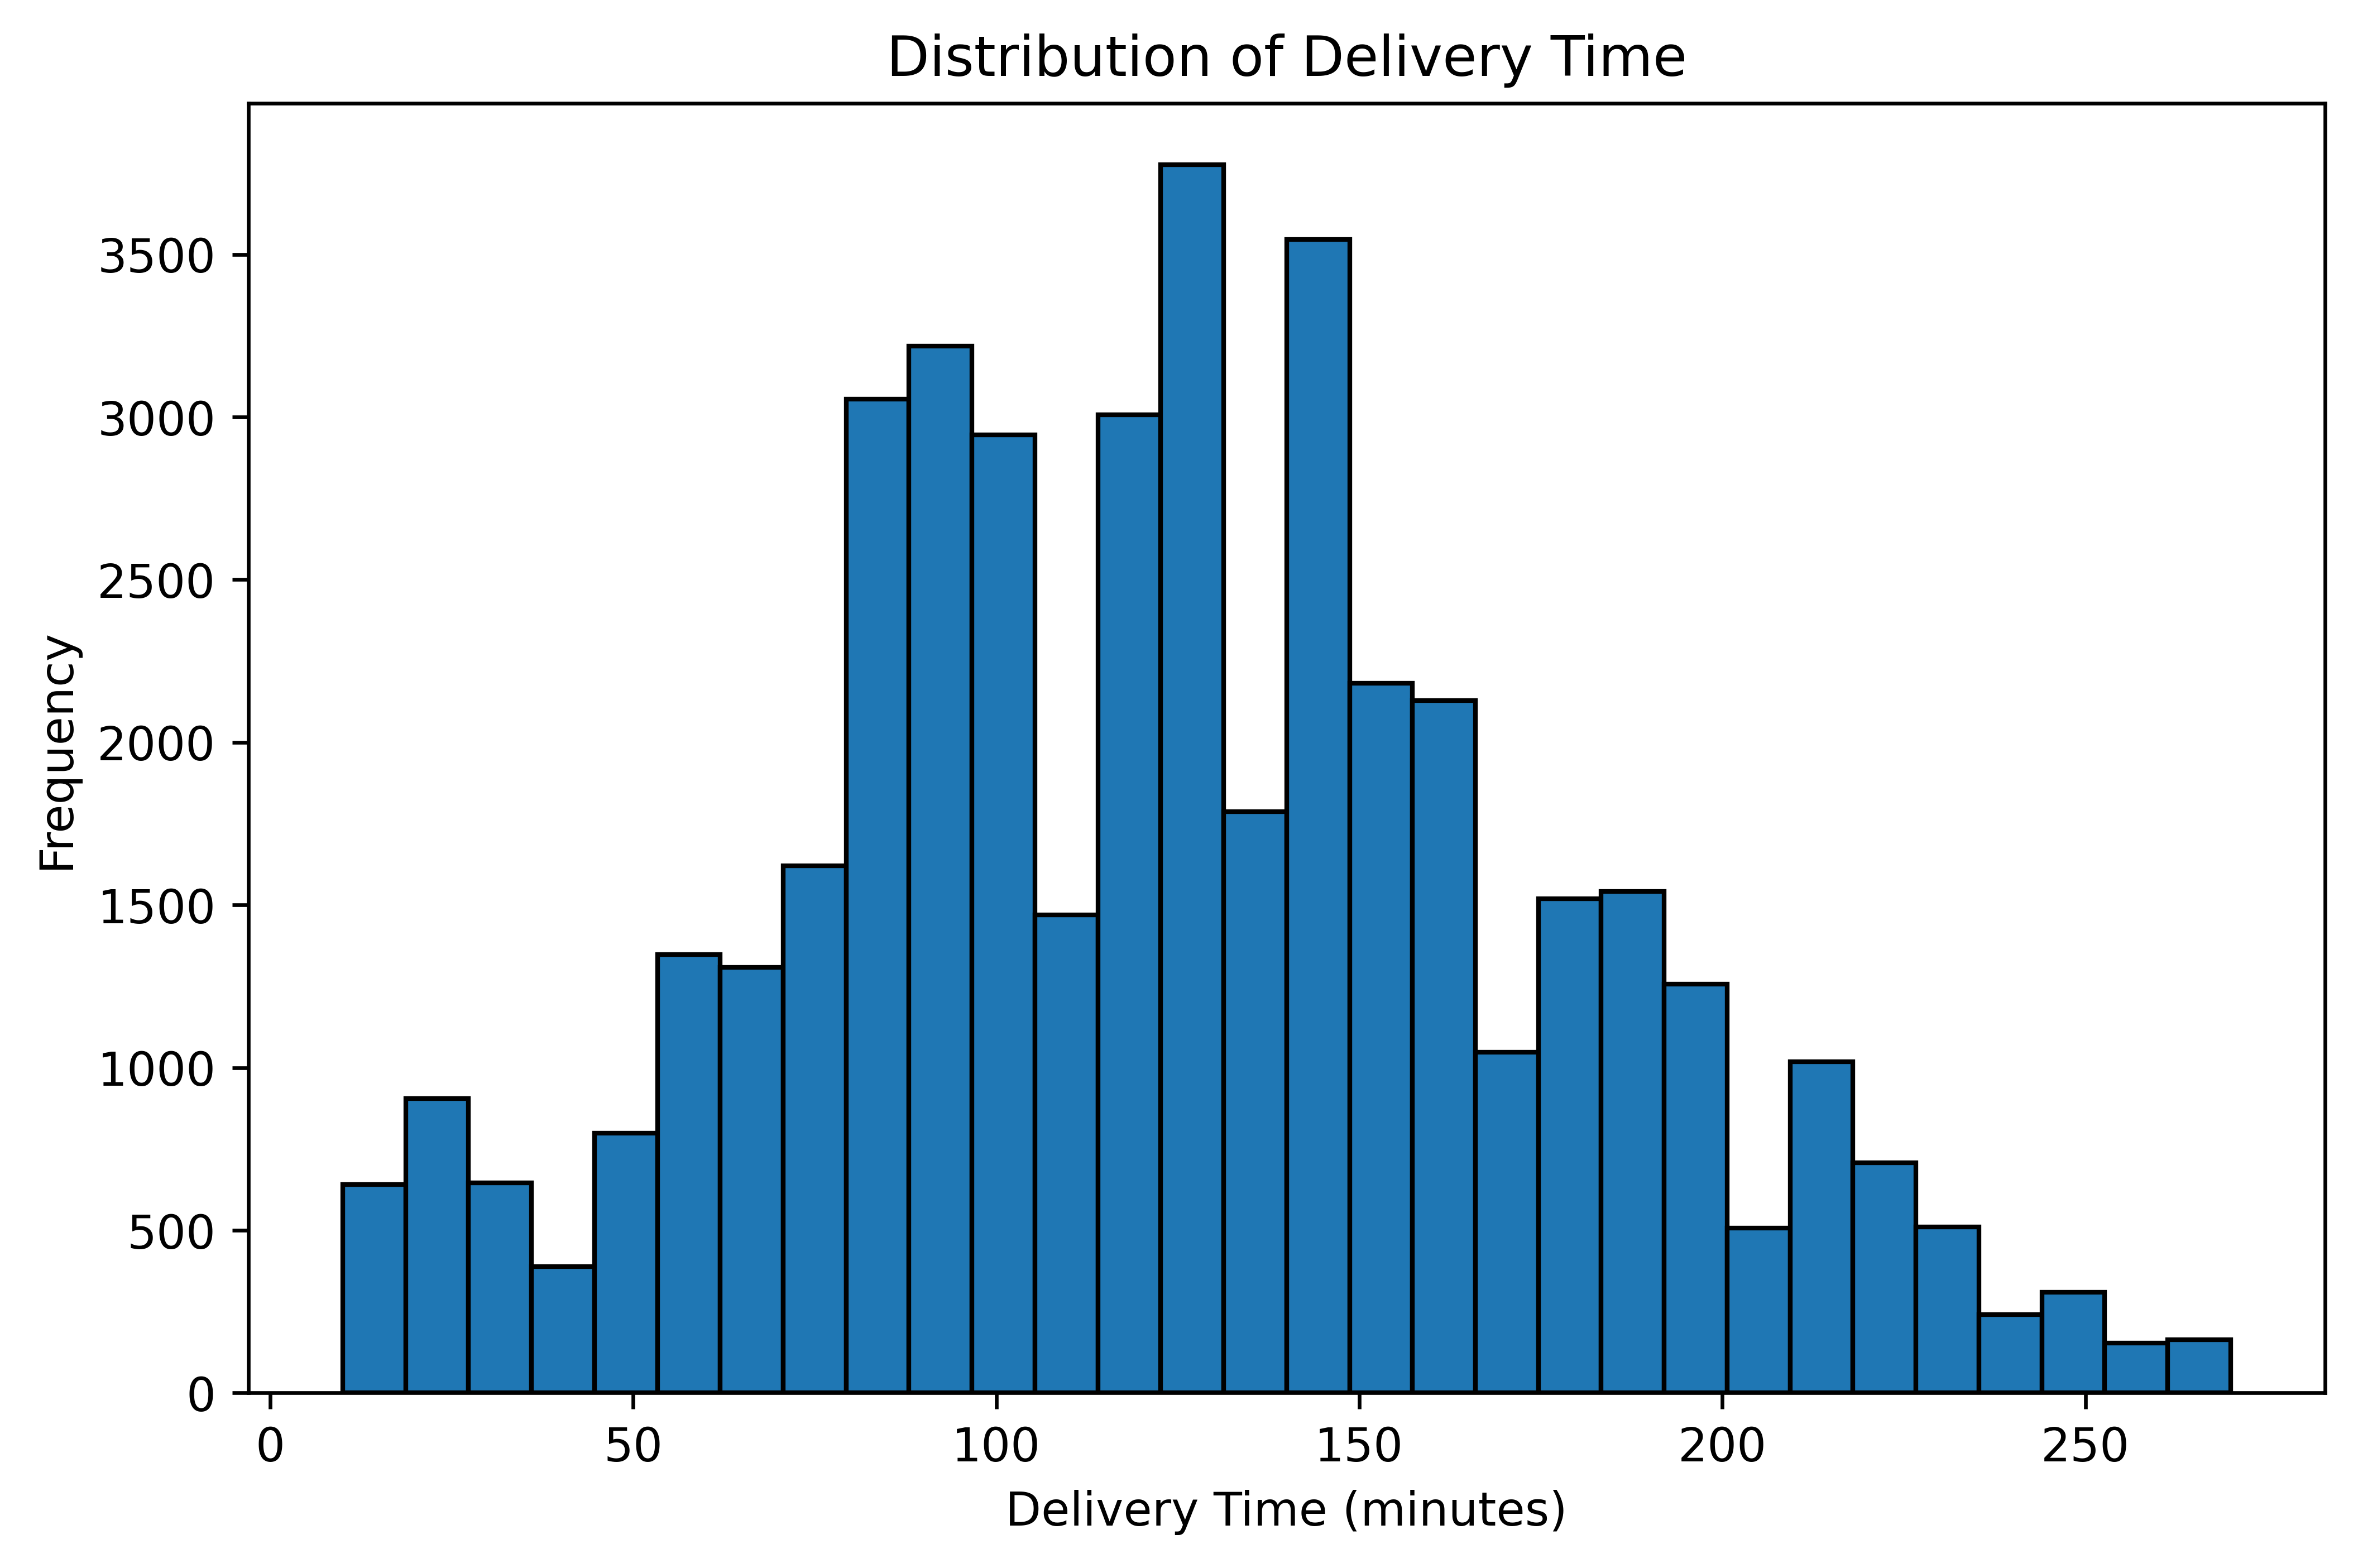

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=600)

plt.hist(df["Delivery_Time"], bins=30, edgecolor="black")

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")

plt.show()

In [ ]:
# Predict test set using the best Random Forest model

rf_pred = best_rf_model.predict(X_test)

rf_test_results = X_test.copy()

rf_test_results["Actual_Time"] = y_test.values
rf_test_results["Predicted_Time"] = rf_pred

# Actual and predicted risk levels

rf_test_results["Actual_Risk"] = (
    rf_test_results["Actual_Time"].apply(get_risk_level)
)

rf_test_results["Predicted_Risk"] = (
    rf_test_results["Predicted_Time"].apply(get_risk_level)
)

display(
    rf_test_results[
        [
            "Actual_Time",
            "Predicted_Time",
            "Actual_Risk",
            "Predicted_Risk"
        ]
    ].head(10)
)

,Actual_Time,Predicted_Time,Actual_Risk,Predicted_Risk
20794,145,116.321244,MEDIUM,LOW
37635,21,28.111201,LOW,LOW
14700,165,127.771579,HIGH,MEDIUM
37852,200,182.144315,HIGH,HIGH
6736,145,128.447402,MEDIUM,MEDIUM
6936,180,147.600630,HIGH,MEDIUM
17666,120,128.489538,LOW,MEDIUM
31519,180,194.343682,HIGH,HIGH
25337,155,174.148232,MEDIUM,HIGH
5959,85,108.962275,LOW,LOW


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

labels = ["LOW", "MEDIUM", "HIGH"]

y_actual = rf_test_results["Actual_Risk"]
y_pred = rf_test_results["Predicted_Risk"]

# Confusion Matrix

cm = confusion_matrix(
    y_actual,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print("Confusion Matrix")
display(cm_df)

# Overall metrics

precision = precision_score(
    y_actual, y_pred, average="weighted"
)

recall = recall_score(
    y_actual, y_pred, average="weighted"
)

f1 = f1_score(
    y_actual, y_pred, average="weighted"
)

macro_f1 = f1_score(
    y_actual, y_pred, average="macro"
)

print("Weighted Precision:", round(precision, 3))
print("Weighted Recall:", round(recall, 3))
print("Weighted F1-score:", round(f1, 3))
print("Macro F1-score:", round(macro_f1, 3))

print("\nClassification Report")
print(
    classification_report(
        y_actual,
        y_pred,
        labels=labels,
        digits=3
    )
)

Confusion Matrix


,LOW,MEDIUM,HIGH
LOW,4161,457,42
MEDIUM,822,830,462
HIGH,41,234,1699


Weighted Precision: 0.747
Weighted Recall: 0.765
Weighted F1-score: 0.752
Macro F1-score: 0.71

Classification Report
              precision    recall  f1-score   support

         LOW      0.828     0.893     0.859      4660
      MEDIUM      0.546     0.393     0.457      2114
        HIGH      0.771     0.861     0.814      1974

    accuracy                          0.765      8748
   macro avg      0.715     0.715     0.710      8748
weighted avg      0.747     0.765     0.752      8748



# **Missed High-Risk Case Analysis**

In [ ]:
# Correctly predicted HIGH-risk cases

rf_correct_high = rf_test_results[
    (rf_test_results["Actual_Risk"] == "HIGH") &
    (rf_test_results["Predicted_Risk"] == "HIGH")
].copy()

# Missed HIGH-risk cases

rf_missed_high = rf_test_results[
    (rf_test_results["Actual_Risk"] == "HIGH") &
    (rf_test_results["Predicted_Risk"] != "HIGH")
].copy()

print("Correct HIGH-risk cases:", len(rf_correct_high))
print("Missed HIGH-risk cases:", len(rf_missed_high))

Correct HIGH-risk cases: 1699
Missed HIGH-risk cases: 275


In [ ]:
numeric_features = [
    "Agent_Age",
    "Agent_Rating",
    "Distance_km",
    "Pickup_Wait_Min",
    "Order_Hour"
]

numeric_comparison = pd.DataFrame({
    "Correct_HIGH": rf_correct_high[numeric_features].median(),
    "Missed_HIGH": rf_missed_high[numeric_features].median()
})

display(numeric_comparison.round(2))

,Correct_HIGH,Missed_HIGH
Agent_Age,32.00,31.00
Agent_Rating,4.40,4.70
Distance_km,12.48,9.07
Pickup_Wait_Min,10.00,10.00
Order_Hour,19.00,18.00


In [ ]:
traffic_comparison = pd.DataFrame({
    "Correct_HIGH": rf_correct_high["Traffic"].value_counts(
        normalize=True, dropna=False
    ) * 100,

    "Missed_HIGH": rf_missed_high["Traffic"].value_counts(
        normalize=True, dropna=False
    ) * 100
}).fillna(0)

display(traffic_comparison.round(1))

,Correct_HIGH,Missed_HIGH
Traffic,,
High,7.4,21.1
Jam,59.3,41.1
Low,8.8,9.1
Medium,24.5,27.6
NaN,0.0,1.1


In [ ]:
categorical_features = [
    "Weather",
    "Area",
    "Category",
    "Vehicle"
]

for feature in categorical_features:

    comparison = pd.DataFrame({
        "Correct_HIGH": rf_correct_high[feature].value_counts(normalize=True) * 100,
        "Missed_HIGH": rf_missed_high[feature].value_counts(normalize=True) * 100
    }).fillna(0)

    print(f"\n{feature}")
    display(comparison.round(1))


Weather


,Correct_HIGH,Missed_HIGH
Weather,,
Cloudy,27.0,15.4
Fog,27.4,14.3
Sandstorms,13.7,20.6
Stormy,13.4,21.7
Sunny,6.5,11.0
Windy,12.1,16.9



Area


,Correct_HIGH,Missed_HIGH
Area,,
Metropolitian,84.0,84.7
Other,1.6,1.1
Semi-Urban,1.4,0.0
Urban,12.9,14.2



Category


,Correct_HIGH,Missed_HIGH
Category,,
Apparel,6.6,7.6
Books,7.7,6.5
Clothing,5.9,4.7
Cosmetics,7.0,5.1
Electronics,6.2,8.7
Home,7.9,5.5
Jewelry,7.2,8.7
Kitchen,6.9,7.6
Outdoors,6.1,5.8



Vehicle


,Correct_HIGH,Missed_HIGH
Vehicle,,
motorcycle,68.5,66.2
scooter,26.1,27.3
van,5.4,6.5


- #### Missed high-risk cases tended to have shorter delivery distances and higher agent ratings. They also showed different traffic and weather patterns, with fewer cases under traffic jams and more cases under high or medium traffic conditions. For weather, missed high-risk cases were more frequently associated with stormy and sandstorm conditions, while cloudy and foggy conditions were more common among correctly identified high-risk cases. In contrast, area, product category, and vehicle type showed relatively small differences between correctly identified and missed high-risk cases.

# **Actionable Recommendations for High-Risk Deliveries**

In [ ]:
high_risk_deliveries = rf_test_results[
    rf_test_results["Predicted_Risk"] == "HIGH"
].copy()

def recommend_action(row):
    actions = []

    if row["Distance_km"] > 12:
        actions.append("Dispatch earlier")

    if row["Traffic"] == "Jam ":
        actions.append("Optimize route")

    if row["Weather"] in ["Stormy", "Sandstorms"]:
        actions.append("Monitor weather")

    if not actions:
        actions.append("Monitor delivery closely")

    return "; ".join(actions)

high_risk_deliveries["Recommended_Action"] = (
    high_risk_deliveries.apply(recommend_action, axis=1)
)

display(
    high_risk_deliveries[
        [
            "Predicted_Time",
            "Predicted_Risk",
            "Distance_km",
            "Traffic",
            "Weather",
            "Recommended_Action"
        ]
    ].head(10)
)

,Predicted_Time,Predicted_Risk,Distance_km,Traffic,Weather,Recommended_Action
37852,182.144315,HIGH,16.819857,Jam,Fog,Dispatch earlier; Optimize route
31519,194.343682,HIGH,20.253089,Medium,Fog,Dispatch earlier
25337,174.148232,HIGH,17.297866,Medium,Cloudy,Dispatch earlier
10175,194.343682,HIGH,19.363383,Medium,Fog,Dispatch earlier
29576,227.411480,HIGH,19.761050,Jam,Fog,Dispatch earlier; Optimize route
28487,194.406730,HIGH,16.902807,Medium,Fog,Dispatch earlier
24425,166.812113,HIGH,7.448970,Jam,Windy,Optimize route
32146,186.011507,HIGH,17.137491,Medium,Cloudy,Dispatch earlier
32105,176.054886,HIGH,19.659851,Medium,Fog,Dispatch earlier
14511,239.634708,HIGH,7.802794,Jam,Sunny,Optimize route
